# 卷积神经网络

卷积神经网络（Convolutional Neural Network，CNN）是一种在计算机视觉领域取得了巨大成功的深度学习模型。它们的设计灵感来自于生物学中的视觉系统，旨在模拟人类视觉处理的方式。在过去的几年中，CNN已经在图像识别、目标检测、图像生成和许多其他领域取得了显著的进展，成为了计算机视觉和深度学习研究的重要组成部分。


## 一、图像原理

在了解卷积神经网络前，我们先来看看图像的原理：

图像在计算机中是一堆按顺序排列的数字，数值为0到255。0表示最暗，255表示最亮。 如下图：

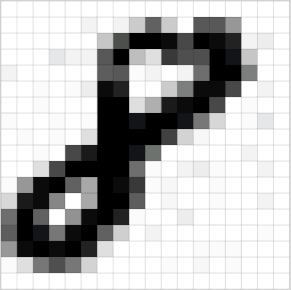


上图是只有黑白颜色的灰度图，而更普遍的图片表达方式是RGB颜色模型，即红、绿、蓝三原色的色光以不同的比例相加，以产生多种多样的色光。RGB颜色模型中，单个矩阵就扩展成了有序排列的三个矩阵，也可以用三维张量去理解。

其中的每一个矩阵又叫这个图片的一个channel（通道），宽, 高, 深来描述。

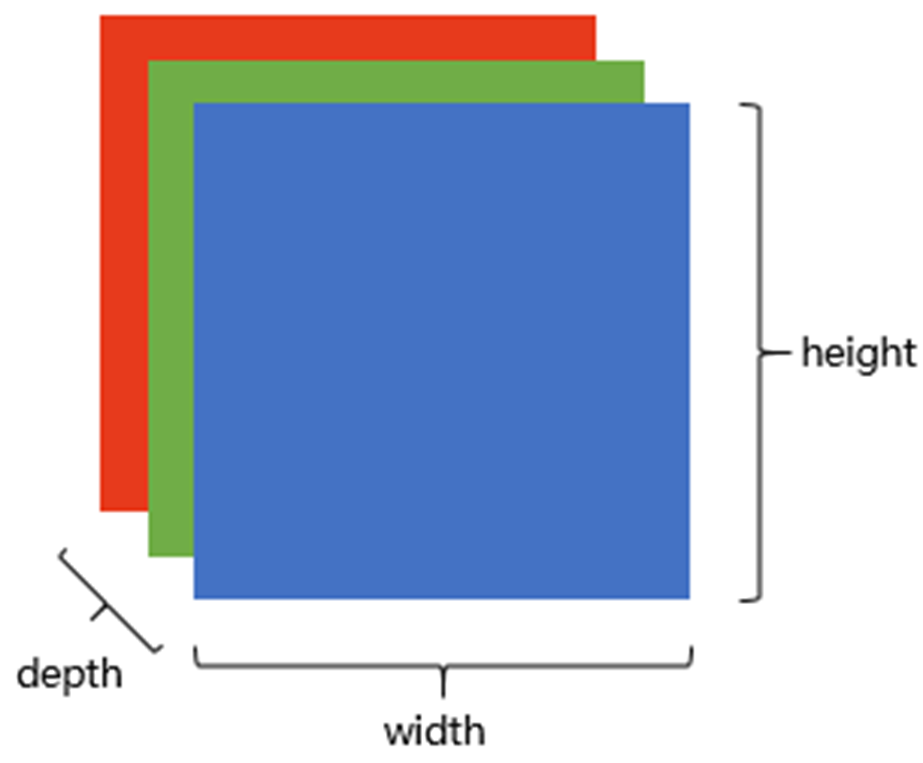

## 二、为什么要学习卷积神经网络

在传统神经网络中，我们要识别下图红色框中的图像时，我们很可能识别不出来，因为这六张图的位置都不通，计算机无法分辨出他们其实是一种形状或物体。

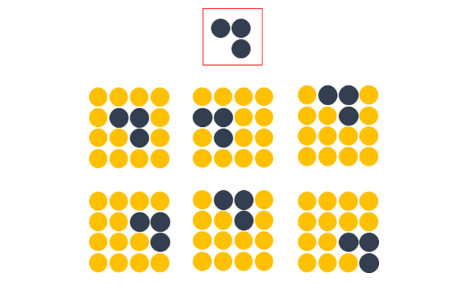

传统神经网络原理如下图：

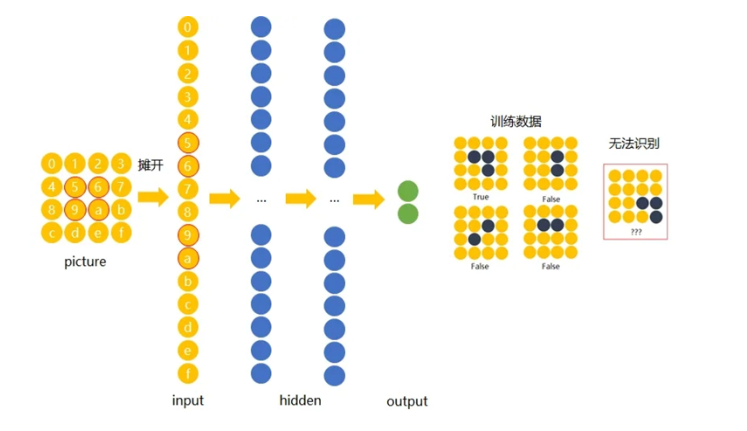

我们希望一个物体不管在画面左侧还是右侧，都会被识别为同一物体，这一特点就是不变性。为了实现平移不变性，卷积神经网络（CNN）等深度学习模型在卷积层中使用了卷积操作，这个操作可以捕捉到图像中的局部特征而不受其位置的影响。

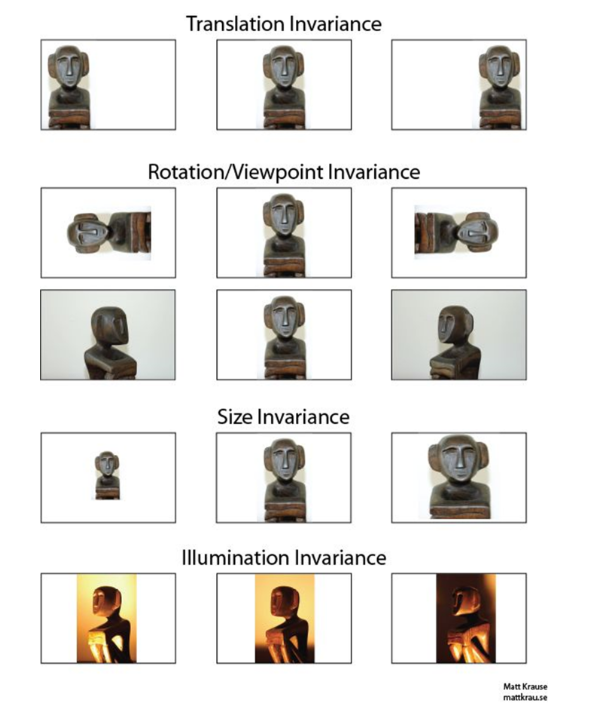

## 三、什么是卷积

在卷积神经网络中，卷积操作是指将一个可移动的小窗口（称为数据窗口，如下图绿色矩形）与图像进行逐元素相乘然后相加的操作。这个小窗口其实是一组固定的权重，它可以被看作是一个特定的滤波器（filter）或卷积核。这个操作的名称“卷积”，源自于这种元素级相乘和求和的过程。这一操作是卷积神经网络名字的来源。

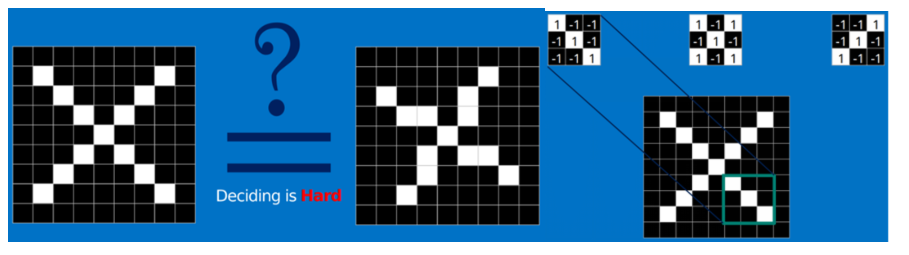

上图这个绿色小窗就是数据窗口。简而言之，卷积操作就是用一个可移动的小窗口来提取图像中的特征，这个小窗口包含了一组特定的权重，通过与图像的不同位置进行卷积操作，网络能够学习并捕捉到不同特征的信息。文字解释可能太难懂，下面直接上动图：

这张图中蓝色的框就是指一个数据窗口，红色框为卷积核（滤波器），最后得到的绿色方形就是卷积的结果（数据窗口中的数据与卷积核逐个元素相乘再求和）

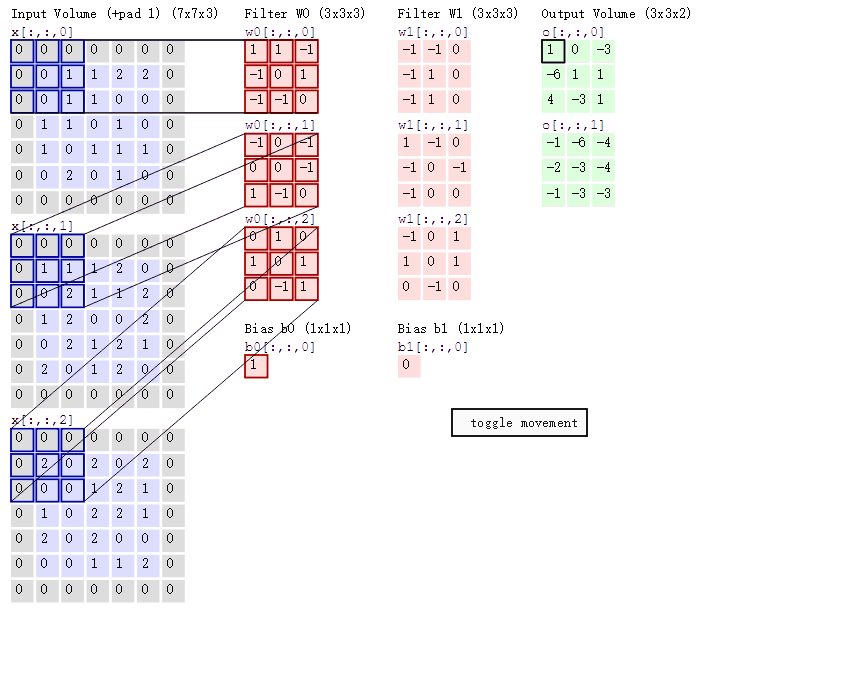

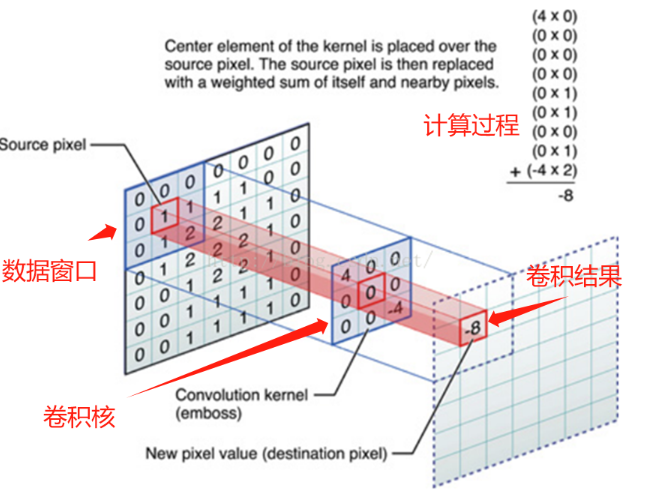

a.步长stride：每次滑动的位置步长。

b. 卷积核的个数：决定输出的depth厚度。同时代表卷积核的个数。

c. 填充值zero-padding：在外围边缘补充若干圈0，方便从初始位置以步长为单位可以刚好滑倒末尾位置，通俗地讲就是为了总长能被步长整除。

为什么要进行数据填充：
假设有一个大小为 4x4 的输入图像：

In [ ]:
[[1, 2, 3, 4],
 [5, 6, 7, 8], 
[9, 10, 11, 12], 
[13, 14, 15, 16]]

现在，我们要应用一个 3x3 的卷积核进行卷积操作，步幅（stride）为 1，且要使用填充（padding）为 1。如果不使用填充，卷积核的中心将无法对齐到输入图像的边缘，导致输出特征图尺寸变小。假设我们使用步幅（stride）为 1 进行卷积，那么在不使用填充的情况下，输出特征图的尺寸将是 2x2。

所以我们要在它的周围填充一圈0，填充为 1 意味着在输入图像的周围添加一圈零值。添加填充后的图像：

In [ ]:
[[0, 0, 0, 0, 0, 0], 
[0, 1, 2, 3, 4, 0], 
[0, 5, 6, 7, 8, 0], 
[0, 9, 10, 11, 12, 0], 
[0, 13, 14, 15, 16, 0], 
[0, 0, 0, 0, 0, 0]]

现在，我们将 3x3 的卷积核应用于这个填充后的输入图像，计算卷积结果，得到大小不变的特征图。

数据填充的主要目的是确保卷积核能够覆盖输入图像的边缘区域，同时保持输出特征图的大小。这对于在CNN中保留空间信息和有效处理图像边缘信息非常重要。

### 卷积神经网络的模型是什么样的？

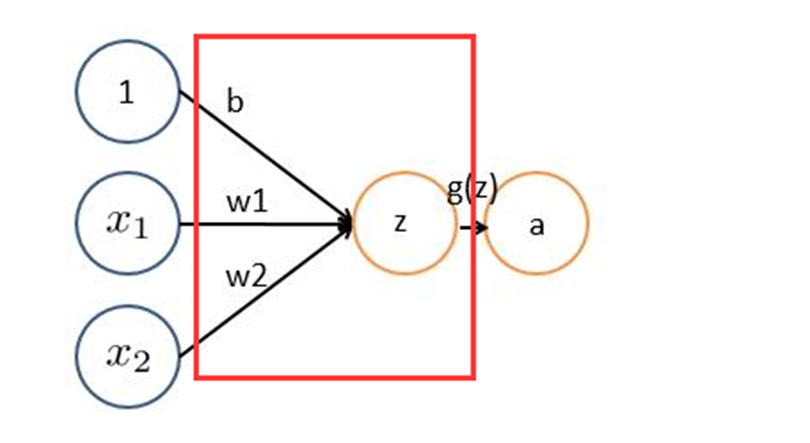

上面红框框起来的部分便可以理解为一个滤波器，即带着一组固定权重的神经元。多个滤波器叠加便成了卷积层。

## 四、卷积神经网络的构造

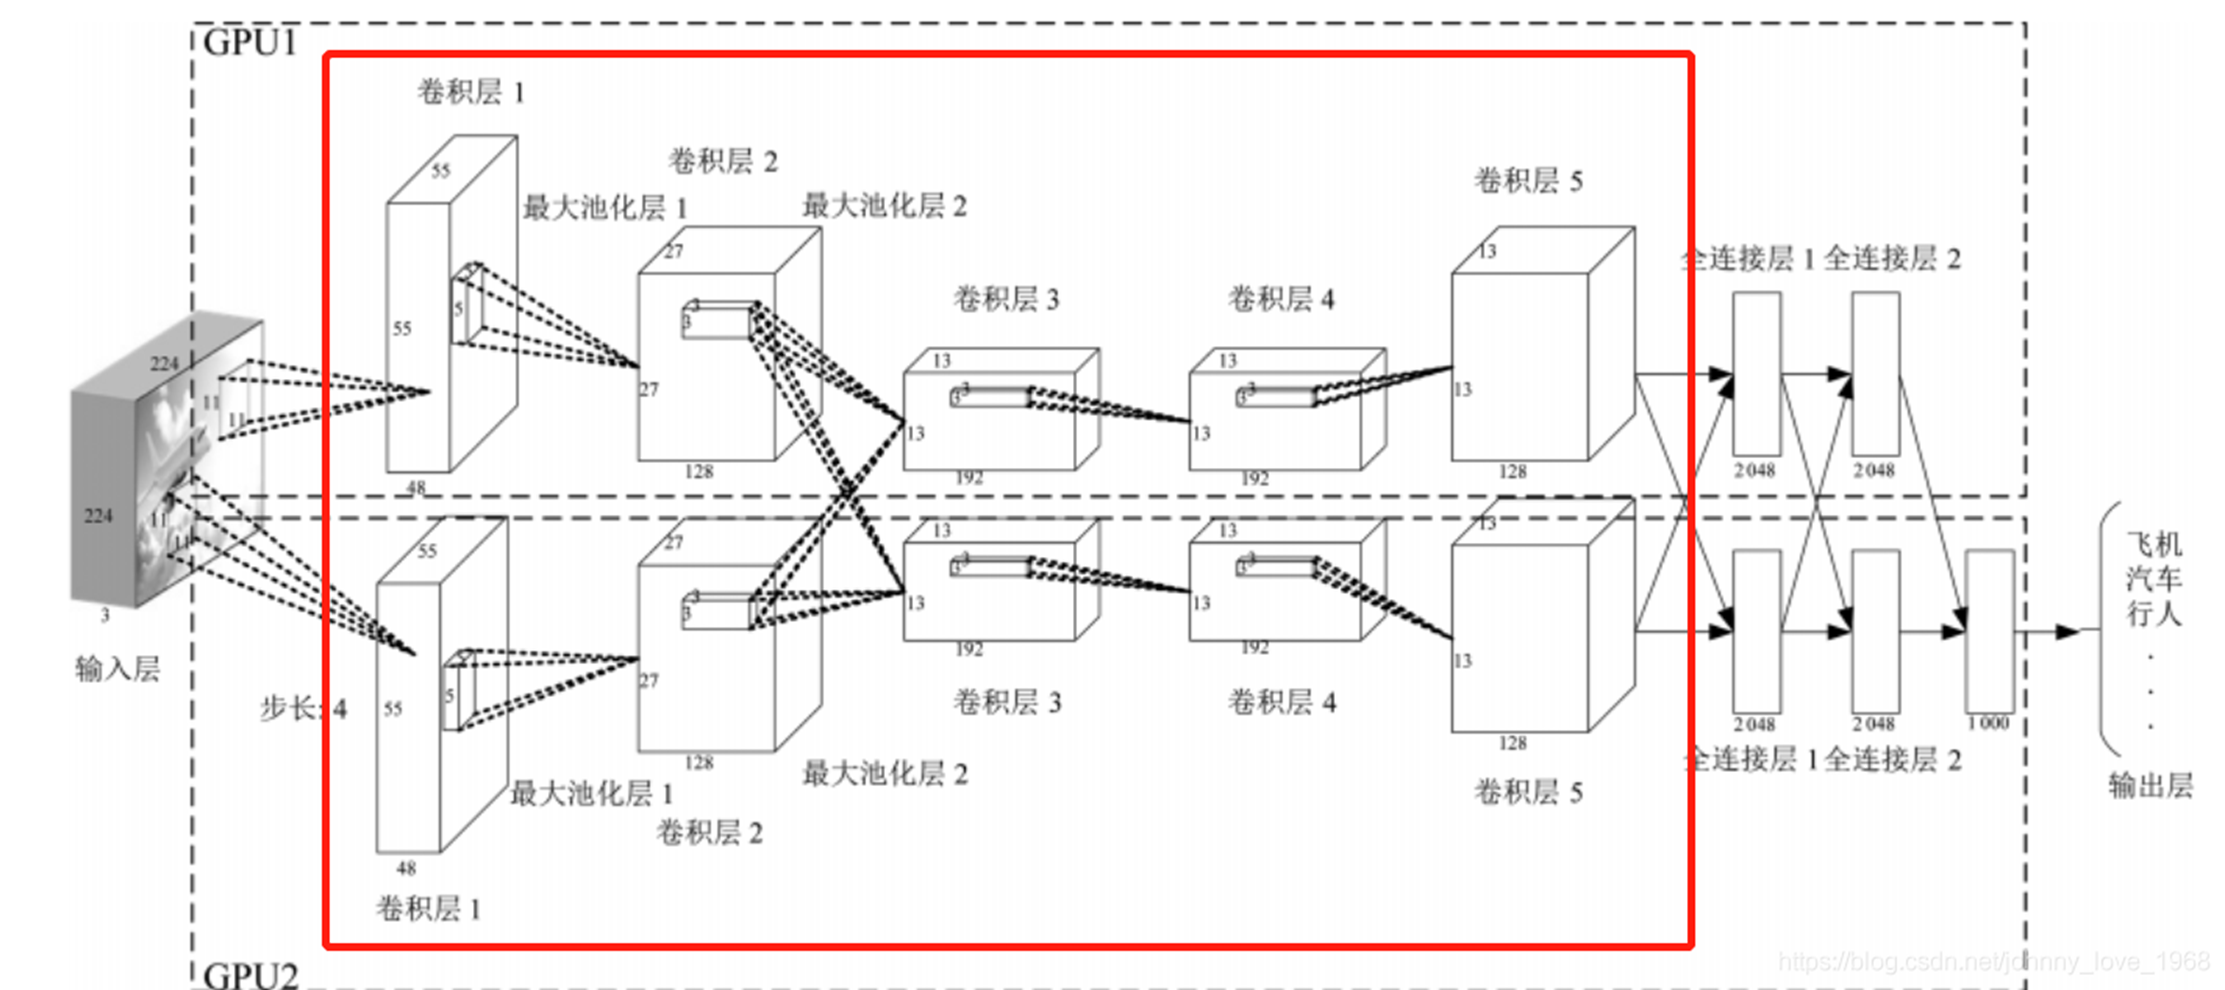

整体架构：
* 输入层

输入层接收原始图像数据。图像通常由三个颜色通道（红、绿、蓝）组成，形成一个二维矩阵，表示像素的强度值

* 卷积和激活层

卷积层将输入图像与卷积核进行卷积操作。然后，通过应用激活函数（如ReLU）来引入非线性。这一步使网络能够学习复杂的特征。

* 池化层

池化层通过减小特征图的大小来减少计算复杂性。它通过选择池化窗口内的最大值或平均值来实现。这有助于提取最重要的特征。

* 全连接层

最后，全连接层将提取的特征映射转化为网络的最终输出。这可以是一个分类标签、回归值或其他任务的结果。


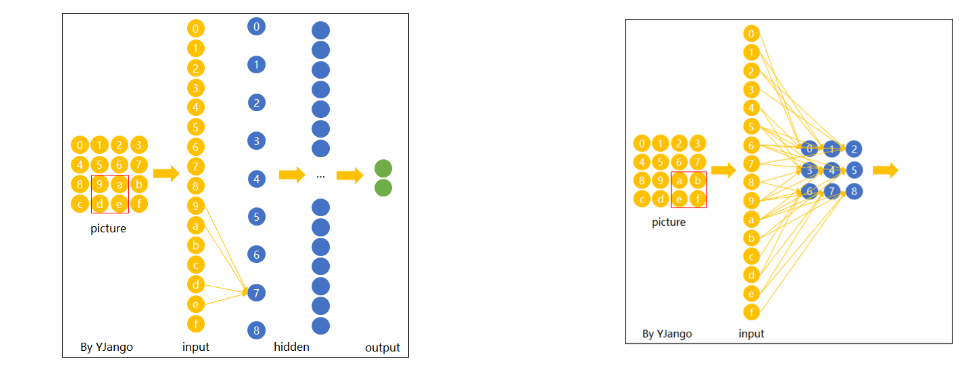

卷积层涉及参数:
* 滑动窗口步长:1
* 卷积核尺寸:3*3
* 边缘填充
* 卷积核个数

步长小的时候提取到的特征将更将丰富，步长大的时候提取的特征就更加粗糙

卷积核小的时候提取特征丰富

边缘填充(padding)，当数据边缘卷积也很重要时，需要在图像外一圈增加0数据来使边缘数据重要化

**卷积结果计算公式:**

* 长度:${H_2 = \frac{H_1-F_H+2P}{S}+1}$

* 宽度:${W_2 = \frac{W_1-F_W+2P}{S}+1}$

* 其中 ${W1}$、${H1}$ 表示输入的宽度、长度; ${W2}$、${H2}$ 表示输出特征图的宽度、长度;${F}$ 表示卷积核长和宽的大小; ${S}$ 表示滑动窗口的步长; ${P}$ 表示边界填充(边界填充) 

**池化层：**

downsampling (下采样)，在原始数据上通过某种方式进行筛选

* Maxpooling:  选择一个区域(2*2,3*3,...),将其中最大值保留其他值去除

**整体网络架构:**

只有带权重参数的层(eg. cov, FC)，能够被计算成一层神经网络


## 经典网络
**Vgg**
**ResNet**

* 经典神经网络遇到的问题: 层数越大反而效果越差
* 解决方案: 引入Resnet（残差神经网络）

**感受野**
最后获得的参数由多大的原始数据获取而来。

* 假设输入大小都是h*w*c, 并且都用c个卷积核（得到c个特征图）, 可以来计算一下其各自所需参数:

一个7*7卷积核所需参数: $\\$                           
 $ = C \times (7 \times 7 \times C) = 49C^2 $     
三个3*3卷积核所需参数: $\\$    
$=3 \times C \times (3 \times 3 \times C) = 27C^2 $

很明显，堆叠小的卷积核所需的参数更少一些